## 1. Research question

I want to test whether learned machine-learning models can use spatial and system-level relationships to predict flood-scenario severity for breach locations that were not observed during training.

I use a location-level group split because the same breach location appears across multiple return periods. A random row split would therefore make the test artificially easy by allowing information from a location in the training set to appear again in the test set.

### Experimental design

- Target: `log1p(scenario damage)`
- Group split: breach location
- Test: completely unseen breach locations
- Baseline 1: global mean
- Baseline 2: return-period mean
- Baseline 3: spatial neighbour interpolation
- Model 1: Random Forest


## 2. Imports

I load the packages needed for the modelling and evaluation steps. I keep the imports together so that the rest of the notebook is easier to reproduce.


In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor

## 3. Project path

I use the project-relative path structure here rather than hard-coding a machine-specific location. This keeps the notebook portable while preserving the same processed-data setup used in the earlier notebooks.


In [ ]:

ROOT = Path("..").resolve()

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"

FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "models"

for directory in [
    RESULTS_DIR,
    FIG_DIR,
    TABLE_DIR,
    MODEL_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root")

Project root


## 4. Load the processed scenario catalogue

I load the processed LIWO scenario catalogue created in the earlier reconstruction step. The modelling in this notebook should start from the same cleaned source rather than silently rebuilding the dataset in a different way.


In [ ]:

scenario_path = DATA_DIR / "processed" / "liwo_scenario_catalog.csv"

df = pd.read_csv(scenario_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.head())

Rows: 1856
Columns: 36
   breach_id  breach_location_id  scenario_id                   scenario_name  \
0          1                   1        15121   20a_Pluimpot 1/400000 Osgetij   
1         14                  14        19091                  tp-1d Maas 210   
2         14                  14        19092                     tp Maas 210   
3         14                  14        19093                  tp+1d Maas 210   
4         25                  25         5214  Alphen - Min decimeringshoogte   

   return_period  discharge_m3s           breach_name  \
0         400000            NaN  20a_Extrabreslocatie   
1            125            NaN                  Alem   
2           1250            NaN                  Alem   
3          12500            NaN                  Alem   
4            125            NaN                Alphen   

                                  dijkring          river damage_MEUR  ...  \
0  Dijkring 27 - Tholen en St. Philipsland  Oosterschelde         290

## 5. Prepare the modelling data

I prepare the fields needed for the predictive experiments and keep the target transformation fixed across the different models. The main question is whether spatial and system context provides information that transfers from observed breach locations to unseen ones.


In [5]:
# Convert damage safely
df["damage_MEUR_num"] = pd.to_numeric(
    df["damage_MEUR"],
    errors="coerce"
)

# Return period should be numeric
df["return_period"] = pd.to_numeric(
    df["return_period"],
    errors="coerce"
)

# Target
df["log_damage"] = np.log1p(
    df["damage_MEUR_num"]
)

# Keep observations usable for modelling
model_data = df.dropna(
    subset=[
        "breach_id",
        "return_period",
        "damage_MEUR_num",
        "log_damage",
        "geometry_x",
        "geometry_y",
        "river",
        "dijkring"
    ]
).copy()

model_data = model_data.reset_index(drop=True)

print("Usable rows:", len(model_data))
print("Unique breach locations:", model_data["breach_id"].nunique())
print("Unique return periods:", model_data["return_period"].nunique())

Usable rows: 1830
Unique breach locations: 610
Unique return periods: 26


## 6. One observation per location × return period

I reduce the data to one observation per breach location and return period for the predictive setup. This avoids giving locations with more scenario records disproportionate influence and makes the evaluation unit consistent across the experiments.


In [6]:
rp_location = (
    model_data
    .groupby(
        ["breach_id", "return_period"],
        as_index=False
    )
    .agg(
        damage_MEUR=("damage_MEUR_num", "mean"),
        log_damage=("log_damage", "mean"),
        geometry_x=("geometry_x", "first"),
        geometry_y=("geometry_y", "first"),
        river=("river", "first"),
        dijkring=("dijkring", "first")
    )
)

print("Location × return-period rows:", len(rp_location))
print(
    "Unique locations:",
    rp_location["breach_id"].nunique()
)

Location × return-period rows: 1765
Unique locations: 610


## 7. Define the five location-level splits

I define five location-level train/test splits so that performance is measured on breach locations that the model has not seen during training.

I use the same splits across the benchmark models. That way, differences in performance come from the model or feature set rather than from a different test sample.


In [7]:
gss = GroupShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=42
)

splits = list(
    gss.split(
        rp_location,
        groups=rp_location["breach_id"]
    )
)

for i, (train_idx, test_idx) in enumerate(
    splits,
    start=1
):
    train_tmp = rp_location.iloc[train_idx]
    test_tmp = rp_location.iloc[test_idx]

    overlap = set(
        train_tmp["breach_id"]
    ).intersection(
        test_tmp["breach_id"]
    )

    print(
        f"Split {i}: "
        f"train locations={train_tmp['breach_id'].nunique()}, "
        f"test locations={test_tmp['breach_id'].nunique()}, "
        f"location overlap={len(overlap)}"
    )

Split 1: train locations=488, test locations=122, location overlap=0
Split 2: train locations=488, test locations=122, location overlap=0
Split 3: train locations=488, test locations=122, location overlap=0
Split 4: train locations=488, test locations=122, location overlap=0
Split 5: train locations=488, test locations=122, location overlap=0


## 8. Recreating the spatial neighbour baseline

Before training a more flexible model, I reproduce the hand-designed spatial neighbour baseline.

I want this baseline because it represents a simple version of the intuition I am testing: nearby or system-related locations may have similar consequences. The machine-learning models therefore need to show value beyond this explicit interpolation rule.


In [10]:
def build_neighbor_features(
    test_df,
    train_df,
    k=5
):
    output = []

    for _, row in test_df.iterrows():

        # Same return-period training scenarios
        candidates = train_df[
            train_df["return_period"] == row["return_period"]
        ].copy()

        if len(candidates) == 0:
            candidates = train_df.copy()

        candidate_coords = candidates[
            ["geometry_x", "geometry_y"]
        ].to_numpy()

        dx = (
            candidate_coords[:, 0]
            - row["geometry_x"]
        )

        dy = (
            candidate_coords[:, 1]
            - row["geometry_y"]
        )

        distances_km = (
            np.sqrt(dx**2 + dy**2)
            / 1000
        )

        candidates["distance_km"] = distances_km

        candidates = (
            candidates
            .sort_values("distance_km")
            .head(k)
        )

        # Distance-weighted severity
        distance_weights = np.exp(
            -candidates["distance_km"].to_numpy() / 25
        )

        weighted_damage = np.average(
            candidates["log_damage"],
            weights=distance_weights
        )

        # System-aware features
        same_river = (
            candidates["river"] == row["river"]
        )

        same_dijkring = (
            candidates["dijkring"] == row["dijkring"]
        )

        river_damage = (
            candidates.loc[
                same_river,
                "log_damage"
            ].mean()
            if same_river.any()
            else candidates["log_damage"].mean()
        )

        dijkring_damage = (
            candidates.loc[
                same_dijkring,
                "log_damage"
            ].mean()
            if same_dijkring.any()
            else candidates["log_damage"].mean()
        )

        output.append({
            "breach_id": row["breach_id"],
            "return_period": row["return_period"],
            "target_log_damage": row["log_damage"],

            "nearest_distance_km":
                candidates["distance_km"].min(),

            "mean_neighbor_distance_km":
                candidates["distance_km"].mean(),

            "distance_weighted_damage":
                weighted_damage,

            "same_river_neighbor_damage":
                river_damage,

            "same_dijkring_neighbor_damage":
                dijkring_damage,

            "mean_neighbor_damage":
                candidates["log_damage"].mean(),

            "n_neighbors":
                len(candidates)
        })

    return pd.DataFrame(output)

## 9. Reproducing the benchmark across all five splits

I evaluate the spatial benchmark across all five location-level splits rather than relying on one split.

This gives me a more stable estimate of how much the baseline can generalize to completely unseen breach locations.


In [11]:
spatial_results = []

for split_id, (train_idx, test_idx) in enumerate(
    splits,
    start=1
):

    train_split = rp_location.iloc[
        train_idx
    ].copy()

    test_split = rp_location.iloc[
        test_idx
    ].copy()

    features = build_neighbor_features(
        test_split,
        train_split,
        k=5
    )

    y_true = features[
        "target_log_damage"
    ].to_numpy()

    y_pred = features[
        "distance_weighted_damage"
    ].to_numpy()

    spatial_results.append({
        "split": split_id,
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "R2": r2_score(
            y_true,
            y_pred
        )
    })

spatial_results = pd.DataFrame(
    spatial_results
)

spatial_results

,split,MAE,RMSE,R2
0,1,1.144758,1.443116,0.606147
1,2,1.253029,1.738413,0.412862
2,3,1.324982,1.715945,0.515681
3,4,1.211063,1.603197,0.507371
4,5,1.390488,1.879675,0.389272


## 10. Random Forest

I use a Random Forest as the first learned benchmark because it can represent nonlinear relationships between spatial, system, and scenario features without requiring me to specify the functional form beforehand.

The important comparison is against the spatial neighbour baseline, not just the absolute score.


In [18]:
def build_rf_features(
    query_df,
    reference_df,
    k=5,
    exclude_self=True
):
    output = []

    for _, row in query_df.iterrows():

        # First try same-return-period observations
        candidates = reference_df[
            reference_df["return_period"] == row["return_period"]
        ].copy()

        # Remove the target location from its own neighbour set
        if exclude_self:
            candidates = candidates[
                candidates["breach_id"] != row["breach_id"]
            ].copy()

        # If no same-RP neighbours remain, use all other
        # reference observations as fallback
        if len(candidates) == 0:

            candidates = reference_df.copy()

            if exclude_self:
                candidates = candidates[
                    candidates["breach_id"] != row["breach_id"]
                ].copy()

        # If still empty, something is fundamentally wrong
        if len(candidates) == 0:
            raise ValueError(
                f"No reference neighbours available for "
                f"breach_id={row['breach_id']}, "
                f"return_period={row['return_period']}"
            )

        # Calculate distance
        dx = (
            candidates["geometry_x"].to_numpy()
            - row["geometry_x"]
        )

        dy = (
            candidates["geometry_y"].to_numpy()
            - row["geometry_y"]
        )

        candidates["distance_km"] = (
            np.sqrt(dx**2 + dy**2) / 1000
        )

        # Select nearest neighbours
        candidates = (
            candidates
            .sort_values("distance_km")
            .head(k)
            .copy()
        )

        # Distance weights
        weights = np.exp(
            -candidates["distance_km"].to_numpy() / 25
        )

        weight_sum = weights.sum()

        # Safety check
        if weight_sum <= 0:
            weighted_damage = candidates["log_damage"].mean()
        else:
            weighted_damage = np.average(
                candidates["log_damage"].to_numpy(),
                weights=weights
            )

        # Same-river severity
        river_mask = (
            candidates["river"] == row["river"]
        )

        if river_mask.any():
            river_damage = candidates.loc[
                river_mask,
                "log_damage"
            ].mean()
        else:
            river_damage = candidates["log_damage"].mean()

        # Same-dike-ring severity
        dike_mask = (
            candidates["dijkring"] == row["dijkring"]
        )

        if dike_mask.any():
            dike_damage = candidates.loc[
                dike_mask,
                "log_damage"
            ].mean()
        else:
            dike_damage = candidates["log_damage"].mean()

        output.append({
            "return_period": row["return_period"],
            "nearest_distance_km":
                candidates["distance_km"].min(),
            "mean_neighbor_distance_km":
                candidates["distance_km"].mean(),
            "distance_weighted_damage":
                weighted_damage,
            "mean_neighbor_damage":
                candidates["log_damage"].mean(),
            "same_river_neighbor_damage":
                river_damage,
            "same_dijkring_neighbor_damage":
                dike_damage,
            "n_neighbors":
                len(candidates),
            "target_log_damage":
                row["log_damage"],
            "breach_id":
                row["breach_id"]
        })

    return pd.DataFrame(output)

In [19]:
rf_train_features = build_rf_features(
    train_split,
    train_split,
    k=5,
    exclude_self=True
)

rf_test = build_rf_features(
    test_split,
    train_split,
    k=5,
    exclude_self=True
)

print("Train rows:", len(rf_train_features))
print("Test rows:", len(rf_test))

print("\nTraining missing values:")
print(rf_train_features.isna().sum())

print("\nTest missing values:")
print(rf_test.isna().sum())

Train rows: 1402
Test rows: 363

Training missing values:
return_period                    0
nearest_distance_km              0
mean_neighbor_distance_km        0
distance_weighted_damage         0
mean_neighbor_damage             0
same_river_neighbor_damage       0
same_dijkring_neighbor_damage    0
n_neighbors                      0
target_log_damage                0
breach_id                        0
dtype: int64

Test missing values:
return_period                    0
nearest_distance_km              0
mean_neighbor_distance_km        0
distance_weighted_damage         0
mean_neighbor_damage             0
same_river_neighbor_damage       0
same_dijkring_neighbor_damage    0
n_neighbors                      0
target_log_damage                0
breach_id                        0
dtype: int64


In [ ]:
# train the Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_features = [
    "return_period",
    "nearest_distance_km",
    "mean_neighbor_distance_km",
    "distance_weighted_damage",
    "mean_neighbor_damage",
    "same_river_neighbor_damage",
    "same_dijkring_neighbor_damage",
    "n_neighbors"
]

X_train = rf_train_features[rf_features]
y_train = rf_train_features["target_log_damage"]

X_test = rf_test[rf_features]
y_test = rf_test["target_log_damage"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (1402, 8)
X_test : (363, 8)


In [ ]:

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest results
---------------------
MAE : 1.2576980252419214
RMSE: 1.5811094363289075
R²  : 0.5272237981702759


In [22]:
# Return-period baseline
rp_means = (
    train_split
    .groupby("return_period")["log_damage"]
    .mean()
)

rp_pred = (
    test_split["return_period"]
    .map(rp_means)
    .fillna(train_split["log_damage"].mean())
    .to_numpy()
)

# Spatial baseline
spatial_pred = rf_test[
    "distance_weighted_damage"
].to_numpy()

comparison = pd.DataFrame({
    "Model": [
        "Return-period baseline",
        "Spatial neighbour baseline",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, rp_pred),
        mean_absolute_error(y_test, spatial_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rp_pred)),
        np.sqrt(mean_squared_error(y_test, spatial_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2": [
        r2_score(y_test, rp_pred),
        r2_score(y_test, spatial_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Return-period baseline,1.516750,1.892867,0.322402
1,Spatial neighbour baseline,1.144758,1.443116,0.606147
2,Random Forest,1.257698,1.581109,0.527224


In [23]:
rf_cv_results = []

for split_id, (train_idx, test_idx) in enumerate(
    splits,
    start=1
):
    
    train_split = rp_location.iloc[
        train_idx
    ].copy()

    test_split = rp_location.iloc[
        test_idx
    ].copy()

    # Build leakage-safe features
    rf_train_features = build_rf_features(
        train_split,
        train_split,
        k=5,
        exclude_self=True
    )

    rf_test_features = build_rf_features(
        test_split,
        train_split,
        k=5,
        exclude_self=True
    )

    X_train = rf_train_features[rf_features]
    y_train = rf_train_features["target_log_damage"]

    X_test = rf_test_features[rf_features]
    y_test = rf_test_features["target_log_damage"]

    # Train RF
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    rf_cv_results.append({
        "split": split_id,
        "MAE": mean_absolute_error(
            y_test,
            pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        ),
        "R2": r2_score(
            y_test,
            pred
        )
    })

rf_cv_results = pd.DataFrame(
    rf_cv_results
)

print(rf_cv_results)

print("\nMean:")
print(
    rf_cv_results[
        ["MAE", "RMSE", "R2"]
    ].mean()
)

print("\nStd:")
print(
    rf_cv_results[
        ["MAE", "RMSE", "R2"]
    ].std()
)

   split       MAE      RMSE        R2
0      1  1.257698  1.581109  0.527224
1      2  1.262421  1.742366  0.410188
2      3  1.278964  1.653665  0.550199
3      4  1.230090  1.610740  0.502725
4      5  1.329656  1.773408  0.456375

Mean:
MAE     1.271766
RMSE    1.672258
R2      0.489342
dtype: float64

Std:
MAE     0.036828
RMSE    0.083043
R2      0.056280
dtype: float64


In [ ]:

# Complete 5-split comparison

comparison_rows = []

for split_id, (train_idx, test_idx) in enumerate(
    splits,
    start=1
):

    train_split = rp_location.iloc[
        train_idx
    ].copy()

    test_split = rp_location.iloc[
        test_idx
    ].copy()

    y_test = test_split["log_damage"].to_numpy()

   
    # 1. Return-period baseline
   
    rp_means = (
        train_split
        .groupby("return_period")["log_damage"]
        .mean()
    )

    rp_pred = (
        test_split["return_period"]
        .map(rp_means)
        .fillna(train_split["log_damage"].mean())
        .to_numpy()
    )

    
    # 2. Spatial neighbour baseline
    
    spatial_features = build_neighbor_features(
        test_split,
        train_split,
        k=5
    )

    spatial_pred = (
        spatial_features["distance_weighted_damage"]
        .to_numpy()
    )

     
    # 3. Random Forest features
     
    rf_train_features = build_rf_features(
        train_split,
        train_split,
        k=5,
        exclude_self=True
    )

    rf_test_features = build_rf_features(
        test_split,
        train_split,
        k=5,
        exclude_self=True
    )

    X_train = rf_train_features[rf_features]
    y_train = rf_train_features["target_log_damage"]

    X_test = rf_test_features[rf_features]

     
    # 4. Random Forest
    
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    rf_pred = rf.predict(X_test)

     
    # 5. Metrics
     
    for model_name, prediction in [
        ("Return-period", rp_pred),
        ("Spatial neighbour", spatial_pred),
        ("Random Forest", rf_pred)
    ]:

        comparison_rows.append({
            "split": split_id,
            "model": model_name,
            "MAE": mean_absolute_error(
                y_test,
                prediction
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_test,
                    prediction
                )
            ),
            "R2": r2_score(
                y_test,
                prediction
            )
        })

comparison_results = pd.DataFrame(
    comparison_rows
)

print(comparison_results)

    split              model       MAE      RMSE        R2
0       1      Return-period  1.516750  1.892867  0.322402
1       1  Spatial neighbour  1.144758  1.443116  0.606147
2       1      Random Forest  1.257698  1.581109  0.527224
3       2      Return-period  1.659493  2.108803  0.136014
4       2  Spatial neighbour  1.253029  1.738413  0.412862
5       2      Random Forest  1.262421  1.742366  0.410188
6       3      Return-period  1.711693  2.068418  0.296277
7       3  Spatial neighbour  1.324982  1.715945  0.515681
8       3      Random Forest  1.278964  1.653665  0.550199
9       4      Return-period  1.551505  1.894842  0.311836
10      4  Spatial neighbour  1.211063  1.603197  0.507371
11      4      Random Forest  1.230090  1.610740  0.502725
12      5      Return-period  1.737895  2.182038  0.176986
13      5  Spatial neighbour  1.390488  1.879675  0.389272
14      5      Random Forest  1.329656  1.773408  0.456375


In [27]:
comparison_summary = (
    comparison_results
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .sort_values("R2_mean", ascending=False)
)

comparison_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
model,,,,,,
Random Forest,1.271766,0.036828,1.672258,0.083043,0.489342,0.056280
Spatial neighbour,1.264864,0.095989,1.676069,0.163179,0.486266,0.087290
Return-period,1.635467,0.097497,2.029394,0.130262,0.248703,0.085911


The Random Forest gives a small improvement in mean predictive performance over the spatial neighbour baseline and a larger improvement over the return-period-only baseline.

I take this as evidence that there is transferable structure beyond return period alone, but not as evidence that the model has learned a physical flood process.


## Feature importance

I inspect feature importance to understand which inputs the Random Forest is using.

At this stage I treat the importance values as diagnostic rather than causal: they tell me which features are useful for this prediction task, not which variables physically determine flood damage.


In [28]:
# Train a final RF on the first split so we can inspect feature importance
train_idx, test_idx = splits[0]

train_split = rp_location.iloc[train_idx].copy()
test_split = rp_location.iloc[test_idx].copy()

rf_train_features = build_rf_features(
    train_split,
    train_split,
    k=5,
    exclude_self=True
)

rf_test_features = build_rf_features(
    test_split,
    train_split,
    k=5,
    exclude_self=True
)

X_train = rf_train_features[rf_features]
y_train = rf_train_features["target_log_damage"]

X_test = rf_test_features[rf_features]
y_test = rf_test_features["target_log_damage"]

rf_final = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

importance = (
    pd.Series(
        rf_final.feature_importances_,
        index=rf_features
    )
    .sort_values(ascending=False)
)

importance

same_river_neighbor_damage       0.220614
distance_weighted_damage         0.217822
mean_neighbor_damage             0.186338
same_dijkring_neighbor_damage    0.169522
mean_neighbor_distance_km        0.086988
nearest_distance_km              0.083009
return_period                    0.035707
n_neighbors                      0.000000
dtype: float64

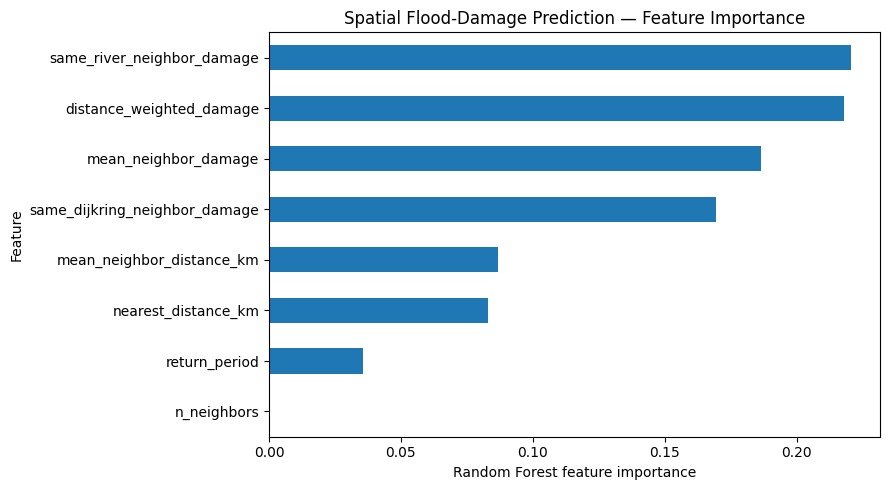

In [29]:
import matplotlib.pyplot as plt

importance.sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Spatial Flood-Damage Prediction — Feature Importance")
plt.tight_layout()
plt.show()

## Ablation — What information is actually responsible for the predictive improvement?

The benchmark tells me that the Random Forest works better than the simpler baselines. The next question is what information is responsible for that improvement.

I therefore remove groups of features and compare the resulting out-of-sample performance.


In [30]:
feature_sets = {

    "Full model": [
        "return_period",
        "nearest_distance_km",
        "mean_neighbor_distance_km",
        "distance_weighted_damage",
        "mean_neighbor_damage",
        "same_river_neighbor_damage",
        "same_dijkring_neighbor_damage",
        "n_neighbors"
    ],

    "Without system features": [
        "return_period",
        "nearest_distance_km",
        "mean_neighbor_distance_km",
        "distance_weighted_damage",
        "mean_neighbor_damage",
        "n_neighbors"
    ],

    "Without spatial-distance features": [
        "return_period",
        "distance_weighted_damage",
        "mean_neighbor_damage",
        "same_river_neighbor_damage",
        "same_dijkring_neighbor_damage",
        "n_neighbors"
    ],

    "Without neighbour severity": [
        "return_period",
        "nearest_distance_km",
        "mean_neighbor_distance_km",
        "n_neighbors"
    ]
}

feature_sets

{'Full model': ['return_period',
  'nearest_distance_km',
  'mean_neighbor_distance_km',
  'distance_weighted_damage',
  'mean_neighbor_damage',
  'same_river_neighbor_damage',
  'same_dijkring_neighbor_damage',
  'n_neighbors'],
 'Without system features': ['return_period',
  'nearest_distance_km',
  'mean_neighbor_distance_km',
  'distance_weighted_damage',
  'mean_neighbor_damage',
  'n_neighbors'],
 'Without spatial-distance features': ['return_period',
  'distance_weighted_damage',
  'mean_neighbor_damage',
  'same_river_neighbor_damage',
  'same_dijkring_neighbor_damage',
  'n_neighbors'],
 'Without neighbour severity': ['return_period',
  'nearest_distance_km',
  'mean_neighbor_distance_km',
  'n_neighbors']}

In [31]:
ablation_results = []

for feature_name, features in feature_sets.items():

    for split_id, (train_idx, test_idx) in enumerate(
        splits,
        start=1
    ):

        train_split = rp_location.iloc[
            train_idx
        ].copy()

        test_split = rp_location.iloc[
            test_idx
        ].copy()

        train_features = build_rf_features(
            train_split,
            train_split,
            k=5,
            exclude_self=True
        )

        test_features = build_rf_features(
            test_split,
            train_split,
            k=5,
            exclude_self=True
        )

        X_train = train_features[features]
        y_train = train_features["target_log_damage"]

        X_test = test_features[features]
        y_test = test_features["target_log_damage"]

        model = RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        ablation_results.append({
            "feature_set": feature_name,
            "split": split_id,
            "MAE": mean_absolute_error(
                y_test,
                pred
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_test,
                    pred
                )
            ),
            "R2": r2_score(
                y_test,
                pred
            )
        })

ablation_results = pd.DataFrame(
    ablation_results
)

In [32]:
ablation_summary = (
    ablation_results
    .groupby("feature_set")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .sort_values("R2_mean", ascending=False)
)

ablation_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
feature_set,,,,,,
Full model,1.271766,0.036828,1.672258,0.083043,0.489342,0.056280
Without spatial-distance features,1.279605,0.059566,1.690454,0.111471,0.478117,0.067057
Without system features,1.308416,0.032936,1.704929,0.079899,0.469123,0.057215
Without neighbour severity,1.691157,0.052227,2.099106,0.092027,0.195763,0.079731


## Interpretation

The ablation results show that neighbouring scenario severity is the dominant predictive component of the current spatial ML baseline. Removing neighbour-severity features reduces mean out-of-sample R² from 0.489 to 0.196, while removing distance or system features produces much smaller reductions.

I interpret this as evidence that consequence information transfers across nearby or system-related breach locations. It does not, by itself, establish causal or probabilistic dependence between breach failures.


## Next question

The first model uses neighbouring scenario severity as an input. That is useful for prediction, but it raises a more important question for scenario extension:

**Can I predict scenario severity using only information that is available before observing the target scenario's damage?**

This would make the model more relevant as a component of scenario generation rather than only as an interpolation tool.


In [33]:
print(df.columns.tolist())

['breach_id', 'breach_location_id', 'scenario_id', 'scenario_name', 'return_period', 'discharge_m3s', 'breach_name', 'dijkring', 'river', 'damage_MEUR', 'victims', 'affected', 'model_resolution', 'initial_breach_width', 'max_breach_width', 'breach_growth_method', 'scenario_layer', 'map_id', 'id', 'breachtypes_id', 'dijkringareas_id', 'openwaters_id', 'name', 'code', 'x', 'y', 'notify', 'lt30', 'f30t300', 'f300t3000', 'f3000t30k', 'gt30k', 'dreigende_overstroming', 'geometry_type', 'geometry_x', 'geometry_y', 'damage_MEUR_num', 'log_damage']


In [34]:
print(
    df[
        [
            "return_period",
            "discharge_m3s",
            "initial_breach_width",
            "max_breach_width",
            "breach_growth_method",
            "river",
            "dijkring",
            "geometry_x",
            "geometry_y"
        ]
    ].head()
)

   return_period  discharge_m3s initial_breach_width max_breach_width  \
0         400000            NaN                 10,0                    
1            125            NaN               -999,0                    
2           1250            NaN               -999,0                    
3          12500            NaN               -999,0                    
4            125            NaN              -9999,0            210,0   

  breach_growth_method          river  \
0          automatisch  Oosterschelde   
1                                Maas   
2                                Maas   
3                                Maas   
4                 vast           Maas   

                                  dijkring  geometry_x  geometry_y  
0  Dijkring 27 - Tholen en St. Philipsland       63661      394660  
1                       Dijkring 39 - Alem      153030      421657  
2                       Dijkring 39 - Alem      153030      421657  
3                       Dijkring 39 - 

In [35]:
# Inspect the candidate modelling variables
candidate_cols = [
    "return_period",
    "discharge_m3s",
    "initial_breach_width",
    "max_breach_width",
    "breach_growth_method",
    "river",
    "dijkring",
    "geometry_x",
    "geometry_y"
]

for col in candidate_cols:
    print(f"\n=== {col} ===")
    print("dtype:", df[col].dtype)
    print("missing:", df[col].isna().sum())
    print("unique:", df[col].nunique())

    if df[col].dtype == "object":
        print(df[col].value_counts(dropna=False).head(10))


=== return_period ===
dtype: int64
missing: 0
unique: 26

=== discharge_m3s ===
dtype: float64
missing: 1829
unique: 3

=== initial_breach_width ===
dtype: object
missing: 0
unique: 12
initial_breach_width
10,0       1316
-999,0      213
-9999,0     125
20,0        101
12,0         48
50,0         27
35,0         15
0,0           4
13,57         3
200,0         2
Name: count, dtype: int64

=== max_breach_width ===
dtype: object
missing: 1
unique: 139
max_breach_width
           1056
210,0        99
200,0        83
100,0        75
300,0        18
-9999,0      16
50,0         16
40,0         13
23,0         12
35,0         12
Name: count, dtype: int64

=== breach_growth_method ===
dtype: object
missing: 6
unique: 4
breach_growth_method
               843
automatisch    705
vast           301
NaN              6
3,0              1
Name: count, dtype: int64

=== river ===
dtype: object
missing: 0
unique: 55
river
Oosterschelde    226
Westerschelde    206
Noordzee         191
Waddenzee     

In [36]:
print(
    df[
        [
            "initial_breach_width",
            "max_breach_width"
        ]
    ].drop_duplicates().head(30)
)

   initial_breach_width max_breach_width
0                  10,0                 
1                -999,0                 
4               -9999,0            210,0
7                  50,0                 
15                 50,0             50,0
24              -9999,0                 
30                 10,0             76,0
31                 10,0             73,0
32                 10,0             86,0
33                 10,0             63,0
34                 10,0             21,0
35                 10,0             23,0
36                 10,0             24,0
37                 10,0             27,0
39                 10,0             40,0
40                 10,0             48,0
41                 10,0             45,0
42                 10,0             55,0
43                 10,0             51,0
50                 20,0            200,0
53                 35,0            300,0
54                 12,0            100,0
69              -9999,0             96,0
72              

In [37]:
print(
    "Discharge missing:",
    df["discharge_m3s"].isna().sum()
)
print(
    "Discharge available:",
    df["discharge_m3s"].notna().sum()
)

Discharge missing: 1829
Discharge available: 27


In [38]:
exo = model_data.copy()

# Convert comma-decimal strings to numeric
for col in [
    "initial_breach_width",
    "max_breach_width"
]:
    exo[col] = (
        exo[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )

    exo[col] = pd.to_numeric(
        exo[col],
        errors="coerce"
    )

# Sentinel values represent unavailable/invalid measurements
exo.loc[
    exo["initial_breach_width"].isin([-999, -9999]),
    "initial_breach_width"
] = np.nan

exo.loc[
    exo["max_breach_width"].isin([-9999]),
    "max_breach_width"
] = np.nan

print(
    exo[
        [
            "initial_breach_width",
            "max_breach_width"
        ]
    ].describe()
)

print("\nMissing after cleaning:")
print(
    exo[
        [
            "initial_breach_width",
            "max_breach_width"
        ]
    ].isna().sum()
)

       initial_breach_width  max_breach_width
count           1494.000000        780.000000
mean              11.941908        103.965385
std                9.328657         85.688124
min                0.000000          4.000000
25%               10.000000         35.000000
50%               10.000000         76.500000
75%               10.000000        200.000000
max              200.000000        623.000000

Missing after cleaning:
initial_breach_width     336
max_breach_width        1050
dtype: int64


## Preparing the exogenous dataset

I now construct a dataset that excludes features derived directly from the target damage outcome.

The purpose is to test whether location, system, spatial-context, and scenario information can predict severity without giving the model a neighbouring observed damage value to lean on.


In [39]:
exo_model = exo.copy()

# Initial breach width: median imputation + missingness indicator
exo_model["initial_width_missing"] = (
    exo_model["initial_breach_width"].isna().astype(int)
)

initial_width_median = (
    exo_model["initial_breach_width"].median()
)

exo_model["initial_breach_width_filled"] = (
    exo_model["initial_breach_width"]
    .fillna(initial_width_median)
)

# Treat blank growth-method values as missing
exo_model["growth_method_missing"] = (
    exo_model["breach_growth_method"]
    .isna()
    .astype(int)
)

exo_model["breach_growth_method"] = (
    exo_model["breach_growth_method"]
    .fillna("missing")
)

print(
    exo_model[
        [
            "initial_breach_width",
            "initial_width_missing",
            "initial_breach_width_filled",
            "breach_growth_method",
            "growth_method_missing"
        ]
    ].head()
)

   initial_breach_width  initial_width_missing  initial_breach_width_filled  \
0                  10.0                      0                         10.0   
1                   NaN                      1                         10.0   
2                   NaN                      1                         10.0   
3                   NaN                      1                         10.0   
4                   NaN                      1                         10.0   

  breach_growth_method  growth_method_missing  
0          automatisch                      0  
1                                           0  
2                                           0  
3                                           0  
4                 vast                      0  


In [40]:
exo_features = [
    "return_period",
    "initial_breach_width_filled",
    "initial_width_missing",
    "growth_method_missing",
    "geometry_x",
    "geometry_y",
    "river",
    "dijkring",
    "breach_growth_method"
]

print(exo_model[exo_features].dtypes)
print("\nRows:", len(exo_model))
print("\nMissing:")
print(exo_model[exo_features].isna().sum())

return_period                    int64
initial_breach_width_filled    float64
initial_width_missing            int64
growth_method_missing            int64
geometry_x                       int64
geometry_y                       int64
river                           object
dijkring                        object
breach_growth_method            object
dtype: object

Rows: 1830

Missing:
return_period                  0
initial_breach_width_filled    0
initial_width_missing          0
growth_method_missing          0
geometry_x                     0
geometry_y                     0
river                          0
dijkring                       0
breach_growth_method           0
dtype: int64


### Location-level holdout splits

I reuse the location-level holdout principle here. The test locations are completely unseen during training, so the model has to transfer information from the available context rather than memorize breach-specific outcomes.


In [42]:
exo_rp = (
    exo_model
    .groupby(
        ["breach_id", "return_period"],
        as_index=False
    )
    .agg(
        log_damage=("log_damage", "mean"),
        initial_breach_width_filled=(
            "initial_breach_width_filled", "mean"
        ),
        initial_width_missing=(
            "initial_width_missing", "max"
        ),
        growth_method_missing=(
            "growth_method_missing", "max"
        ),
        breach_growth_method=(
            "breach_growth_method", "first"
        ),
        river=("river", "first"),
        dijkring=("dijkring", "first"),
        geometry_x=("geometry_x", "first"),
        geometry_y=("geometry_y", "first")
    )
)

print("Rows:", len(exo_rp))
print("Locations:", exo_rp["breach_id"].nunique())
print("Return periods:", exo_rp["return_period"].nunique())
print(exo_rp.head())

Rows: 1765
Locations: 610
Return periods: 26
   breach_id  return_period  log_damage  initial_breach_width_filled  \
0          1         400000    5.673323                         10.0   
1         14            125    3.970292                         10.0   
2         14           1250    4.189655                         10.0   
3         14          12500    4.406719                         10.0   
4         25            125    7.244942                         10.0   

   initial_width_missing  growth_method_missing breach_growth_method  \
0                      0                      0          automatisch   
1                      1                      0                        
2                      1                      0                        
3                      1                      0                        
4                      1                      0                 vast   

           river                                 dijkring  geometry_x  \
0  Oosterschelde

In [44]:
exo_location_ids = set(exo_rp["breach_id"])

print(
    "Locations in previous modelling data:",
    len(set(rp_location["breach_id"]))
)

print(
    "Locations in exogenous data:",
    len(exo_location_ids)
)

print(
    "Common locations:",
    len(
        set(rp_location["breach_id"])
        & exo_location_ids
    )
)

Locations in previous modelling data: 610
Locations in exogenous data: 610
Common locations: 610


## Building the exogenous Random Forest using ColumnTransformer + Pipeline

I use a `ColumnTransformer` and `Pipeline` so that preprocessing and model fitting are kept together.

This is mainly a reproducibility and leakage-control step: transformations are fitted within the training data for each split rather than being learned from the full dataset before evaluation.


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

exo_numeric_features = [
    "return_period",
    "initial_breach_width_filled",
    "initial_width_missing",
    "growth_method_missing",
    "geometry_x",
    "geometry_y"
]

exo_categorical_features = [
    "river",
    "dijkring",
    "breach_growth_method"
]

exo_features = (
    exo_numeric_features
    + exo_categorical_features
)

print("Numeric:", exo_numeric_features)
print("Categorical:", exo_categorical_features)

Numeric: ['return_period', 'initial_breach_width_filled', 'initial_width_missing', 'growth_method_missing', 'geometry_x', 'geometry_y']
Categorical: ['river', 'dijkring', 'breach_growth_method']


In [46]:
exo_rf_results = []

for split_id, (train_idx, test_idx) in enumerate(
    splits,
    start=1
):

    # Same location-level split used elsewhere
    train_ids = set(
        rp_location.iloc[train_idx]["breach_id"]
    )
    test_ids = set(
        rp_location.iloc[test_idx]["breach_id"]
    )

    train_exo = exo_rp[
        exo_rp["breach_id"].isin(train_ids)
    ].copy()

    test_exo = exo_rp[
        exo_rp["breach_id"].isin(test_ids)
    ].copy()

    X_train = train_exo[exo_features]
    y_train = train_exo["log_damage"]

    X_test = test_exo[exo_features]
    y_test = test_exo["log_damage"]

    # Encode categorical variables using training data only
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                exo_categorical_features
            ),
            (
                "numeric",
                "passthrough",
                exo_numeric_features
            )
        ]
    )

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "rf",
                RandomForestRegressor(
                    n_estimators=500,
                    min_samples_leaf=3,
                    max_features="sqrt",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)

    exo_rf_results.append({
        "split": split_id,
        "MAE": mean_absolute_error(
            y_test,
            pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        ),
        "R2": r2_score(
            y_test,
            pred
        ),
        "train_locations": len(train_ids),
        "test_locations": len(test_ids)
    })

exo_rf_results = pd.DataFrame(
    exo_rf_results
)

exo_rf_results

,split,MAE,RMSE,R2,train_locations,test_locations
0,1,1.197088,1.474546,0.588804,488,122
1,2,1.227265,1.625002,0.486970,488,122
2,3,1.326900,1.668465,0.542112,488,122
3,4,1.184314,1.567809,0.528879,488,122
4,5,1.393670,1.792495,0.444609,488,122


In [47]:
exo_rf_summary = (
    exo_rf_results[
        ["MAE", "RMSE", "R2"]
    ]
    .agg(["mean", "std"])
)

exo_rf_summary

,MAE,RMSE,R2
mean,1.265847,1.625664,0.518275
std,0.090733,0.118162,0.054913


The exogenous model shows that location, system, and scenario characteristics contain structured information that can outperform the hand-designed spatial interpolation baseline.

For me, this is more useful than the earlier result because these features are available without directly observing the target scenario's damage.


## Next experiment — understanding what the exogenous RF is learning

The exogenous model performs better than the simple baseline, so I now want to understand which information is actually transferable.

I focus on ablations and permutation importance rather than treating the overall R² as the main scientific result.


In [48]:
# Use split 1 for interpretable feature inspection

train_idx, test_idx = splits[0]

train_ids = set(
    rp_location.iloc[train_idx]["breach_id"]
)

test_ids = set(
    rp_location.iloc[test_idx]["breach_id"]
)

train_exo = exo_rp[
    exo_rp["breach_id"].isin(train_ids)
].copy()

test_exo = exo_rp[
    exo_rp["breach_id"].isin(test_ids)
].copy()

X_train = train_exo[exo_features]
y_train = train_exo["log_damage"]

X_test = test_exo[exo_features]
y_test = test_exo["log_damage"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            exo_categorical_features
        ),
        (
            "numeric",
            "passthrough",
            exo_numeric_features
        )
    ]
)

exo_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                n_estimators=500,
                min_samples_leaf=3,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

exo_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['river', 'dijkring',
                                                   'breach_growth_method']),
                                                 ('numeric', 'passthrough',
                                                  ['return_period',
                                                   'initial_breach_width_filled',
                                                   'initial_width_missing',
                                                   'growth_method_missing',
                                                   'geometry_x',
                                                   'geometry_y'])])),
                ('rf',
                 RandomForestRegressor(max_features='sqrt', min_samples_leaf=3,
                                       n_estimators=500, n_jobs=-1,
                                       random_state=42))])

In [49]:
feature_names = (
    exo_rf
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    exo_rf
    .named_steps["rf"]
    .feature_importances_
)

exo_importance = (
    pd.Series(
        importances,
        index=feature_names
    )
    .sort_values(ascending=False)
)

print(exo_importance.head(25))

numeric__geometry_y                                                        0.229860
numeric__geometry_x                                                        0.197403
numeric__return_period                                                     0.042112
categorical__river_Lek                                                     0.031140
categorical__river_Oosterschelde                                           0.028550
numeric__initial_width_missing                                             0.025863
categorical__dijkring_Dijkring 32 - Zeeuwsch Vlaanderen                    0.024693
categorical__dijkring_Dijkring 43 - Betuwe, Tieler- en Culemborgerwaard    0.023516
categorical__breach_growth_method_vast                                     0.019469
categorical__breach_growth_method_                                         0.018313
numeric__initial_breach_width_filled                                       0.017890
categorical__river_Boven Rijn                                              0

In [50]:
importance_summary = {
    "return_period": 0.0,
    "initial_breach_width": 0.0,
    "missing_width": 0.0,
    "growth_method": 0.0,
    "location": 0.0,
    "river": 0.0,
    "dijkring": 0.0
}

for name, value in exo_importance.items():

    if "return_period" in name:
        importance_summary["return_period"] += value

    elif "initial_breach_width_filled" in name:
        importance_summary["initial_breach_width"] += value

    elif "initial_width_missing" in name:
        importance_summary["missing_width"] += value

    elif "growth_method" in name:
        importance_summary["growth_method"] += value

    elif "geometry_x" in name or "geometry_y" in name:
        importance_summary["location"] += value

    elif "river" in name:
        importance_summary["river"] += value

    elif "dijkring" in name:
        importance_summary["dijkring"] += value

pd.Series(
    importance_summary
).sort_values(ascending=False)

location                0.427263
dijkring                0.232226
river                   0.205261
growth_method           0.049386
return_period           0.042112
missing_width           0.025863
initial_breach_width    0.017890
dtype: float64

## Location ablation

**Does the model still work when geographic coordinates are removed?**

I remove raw coordinates to test whether the model is simply using location as a proxy or whether system/context variables carry information that remains useful without the explicit geographic position.


In [51]:
exo_feature_sets = {

    "Full": [
        "return_period",
        "initial_breach_width_filled",
        "initial_width_missing",
        "growth_method_missing",
        "geometry_x",
        "geometry_y",
        "river",
        "dijkring",
        "breach_growth_method"
    ],

    "Without coordinates": [
        "return_period",
        "initial_breach_width_filled",
        "initial_width_missing",
        "growth_method_missing",
        "river",
        "dijkring",
        "breach_growth_method"
    ],

    "Only coordinates": [
        "return_period",
        "geometry_x",
        "geometry_y"
    ],

    "System only": [
        "return_period",
        "river",
        "dijkring",
        "breach_growth_method"
    ]
}

In [52]:
exo_ablation_results = []

for feature_set_name, features in exo_feature_sets.items():

    numeric_features = [
        f for f in features
        if f in exo_numeric_features
    ]

    categorical_features = [
        f for f in features
        if f in exo_categorical_features
    ]

    for split_id, (train_idx, test_idx) in enumerate(
        splits,
        start=1
    ):

        train_ids = set(
            rp_location.iloc[train_idx]["breach_id"]
        )

        test_ids = set(
            rp_location.iloc[test_idx]["breach_id"]
        )

        train_exo = exo_rp[
            exo_rp["breach_id"].isin(train_ids)
        ].copy()

        test_exo = exo_rp[
            exo_rp["breach_id"].isin(test_ids)
        ].copy()

        X_train = train_exo[features]
        y_train = train_exo["log_damage"]

        X_test = test_exo[features]
        y_test = test_exo["log_damage"]

        transformers = []

        if categorical_features:
            transformers.append(
                (
                    "categorical",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    ),
                    categorical_features
                )
            )

        if numeric_features:
            transformers.append(
                (
                    "numeric",
                    "passthrough",
                    numeric_features
                )
            )

        preprocessor = ColumnTransformer(
            transformers=transformers
        )

        model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "rf",
                    RandomForestRegressor(
                        n_estimators=500,
                        min_samples_leaf=3,
                        max_features="sqrt",
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ]
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(X_test)

        exo_ablation_results.append({
            "feature_set": feature_set_name,
            "split": split_id,
            "MAE": mean_absolute_error(
                y_test,
                pred
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_test,
                    pred
                )
            ),
            "R2": r2_score(
                y_test,
                pred
            )
        })

exo_ablation_results = pd.DataFrame(
    exo_ablation_results
)

In [53]:
exo_ablation_summary = (
    exo_ablation_results
    .groupby("feature_set")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .sort_values(
        "R2_mean",
        ascending=False
    )
)

exo_ablation_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
feature_set,,,,,,
Full,1.265847,0.090733,1.625664,0.118162,0.518275,0.054913
Without coordinates,1.296171,0.091102,1.647297,0.107643,0.505967,0.043728
System only,1.305310,0.092423,1.656319,0.111148,0.500395,0.047494
Only coordinates,1.323206,0.095665,1.688149,0.119348,0.480682,0.056234


## Interpretation

Transferable system and context information explains more out-of-sample variation than return period alone, and most of the predictive information remains after removing raw geographic coordinates.

I interpret this as evidence that the model is using more than a simple coordinate-to-damage relationship. It does not mean that geography is irrelevant; rather, system and neighbourhood context appear to provide additional transferable information.


## Permutation importance

I now use permutation importance: I scramble one feature while leaving the others unchanged and measure how much predictive performance deteriorates.

This gives me a second view of what the model is using and helps separate genuinely useful variables from features that are present but contribute little once the other information is available.


In [54]:
from sklearn.inspection import permutation_importance

# Use the already-trained exo_rf from split 1

perm = permutation_importance(
    exo_rf,
    test_exo[exo_features],
    test_exo["log_damage"],
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_importance = (
    pd.DataFrame({
        "feature": exo_features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values(
        "importance_mean",
        ascending=False
    )
)

perm_importance

,feature,importance_mean,importance_std
5,geometry_y,2.290660e-01,1.824561e-02
7,dijkring,2.288260e-01,8.447060e-03
4,geometry_x,2.040292e-01,1.823620e-02
6,river,1.857674e-01,8.921798e-03
8,breach_growth_method,8.811125e-02,3.166225e-03
0,return_period,3.637605e-02,3.796335e-03
2,initial_width_missing,3.428080e-02,4.391234e-03
1,initial_breach_width_filled,2.399072e-02,4.177574e-03
3,growth_method_missing,-4.440892e-17,7.364386e-17


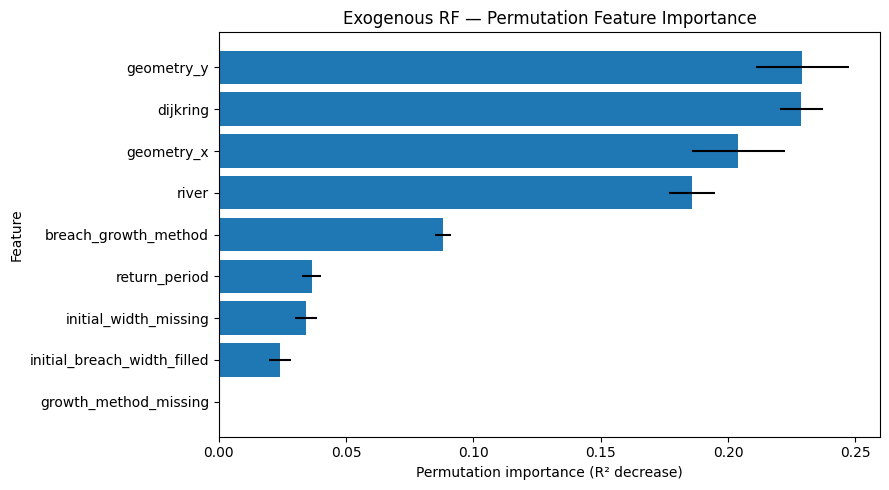

In [55]:
plot_data = (
    perm_importance
    .sort_values("importance_mean")
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["feature"],
    plot_data["importance_mean"],
    xerr=plot_data["importance_std"]
)

plt.xlabel("Permutation importance (R² decrease)")
plt.ylabel("Feature")
plt.title(
    "Exogenous RF — Permutation Feature Importance"
)

plt.tight_layout()
plt.show()

In [ ]:
# Save key experiment results

comparison_results.to_csv(
    TABLE_DIR / "model_comparison_5fold.csv",
    index=False
)

comparison_summary.to_csv(
    TABLE_DIR / "model_comparison_summary.csv"
)

ablation_summary.to_csv(
    TABLE_DIR / "neighbor_rf_ablation.csv"
)

exo_ablation_summary.to_csv(
    TABLE_DIR / "exogenous_rf_ablation.csv"
)

perm_importance.to_csv(
    TABLE_DIR / "exogenous_rf_permutation_importance.csv",
    index=False
)

print("Saved experimental tables to:")
print(TABLE_DIR)

Saved experimental tables to:
